In [1]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, unravel_index, min

In [2]:
def hl2(n, x):
    return spherical_jn(n, x) - 1j * spherical_yn(n, x)

def hl2prime(n, x):
    hn = hl2(n, x)
    hn1 = hl2(n+1, x)
    return n/x * hn - hn1

def hl1(n, x):
    return spherical_jn(n, x) + 1j * spherical_yn(n, x)

def hl1prime(n, x):
    hn = hl1(n, x)
    hn1 = hl1(n+1, x)
    return n/x * hn - hn1

### First we look at kR large

In [3]:
M = 10000
sabs_odd_array = zeros((5, M))
sabs_even_array = zeros((5, M))

x = linspace(1500, 1510, M) # Free space kR
epsilon = 1
y = x * sqrt(epsilon) # epsilonkR in the sphere

n = 3
l_odd_array = linspace(1, 2*n + 1, n+1)
for (l_indx, l_float) in enumerate(l_odd_array):
    l = int(l_float)
    xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
    xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
    yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)

    g_omega = 1j/x # corresponding to sigma being equal to c*epsilon_0

    numerator = epsilon * spherical_jn(l, y) * xhl2_prime - yjl_prime * hl2(l, x) + g_omega * xhl2_prime * yjl_prime
    denominator = -epsilon * spherical_jn(l, y) * xhl1_prime + yjl_prime * hl1(l, x) - g_omega * xhl1_prime * yjl_prime
    sabs_odd_array[l_indx, :] = abs(numerator/denominator)**2
    
l_even_array = linspace(0, 2*n, n+1)
for (l_indx, l_float) in enumerate(l_even_array):
    l = int(l_float)
    xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
    xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
    yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)

    g_omega = 1j/x # corresponding to sigma being equal to c*epsilon_0

    numerator = epsilon * spherical_jn(l, y) * xhl2_prime - yjl_prime * hl2(l, x) + g_omega * xhl2_prime * yjl_prime
    denominator = -epsilon * spherical_jn(l, y) * xhl1_prime + yjl_prime * hl1(l, x) - g_omega * xhl1_prime * yjl_prime
    sabs_even_array[l_indx, :] = abs(numerator/denominator)**2

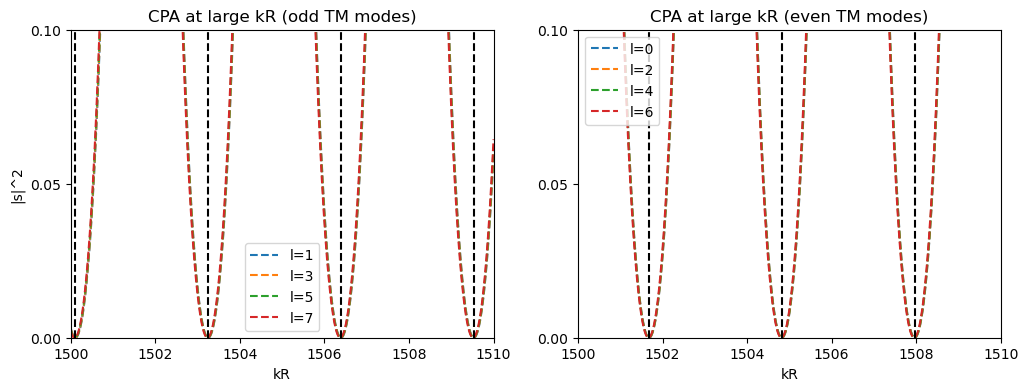

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for (l_indx, l) in enumerate(l_odd_array):
    ax1.plot(x, sabs_odd_array[l_indx, :], linestyle="dashed", label=f"l={int(l)}")
ax1.set_ylim(0, 0.1)
ax1.set_xlim(1500, 1510)
ax1.set_yticks([0, 0.05, 0.1])
ax1.set_xlabel("kR")
ax1.set_ylabel("|s|^2");
ax1.legend()
ax1.vlines([pi/2/sqrt(epsilon)]+pi * linspace(1, 1000, 1000)/sqrt(epsilon), 0, 1, color="black", linestyle="dashed")
ax1.set_title("CPA at large kR (odd TM modes)")

for (l_indx, l) in enumerate(l_even_array):
    ax2.plot(x, sabs_even_array[l_indx, :], linestyle="dashed", label=f"l={int(l)}")
ax2.set_ylim(0, 0.1)
ax2.set_xlim(1500, 1510)
ax2.set_yticks([0, 0.05, 0.1])
ax2.set_xlabel("kR");
ax2.legend();
#ax2.set_ylabel("|s|^2");
ax2.vlines(pi * linspace(1, 1000, 1000)/sqrt(epsilon), 0, 1, color="black", linestyle="dashed");
ax2.set_title("CPA at large kR (even TM modes)");

### We do the same as above but for TE modes

In [5]:
M = 10000
sabs_odd_array = zeros((5, M))
sabs_even_array = zeros((5, M))

x = linspace(1500, 1510, M) # Free space kR
epsilon = 1
y = x * sqrt(epsilon) # epsilonkR in the sphere

n = 3
l_odd_array = linspace(1, 2*n + 1, n+1)
for (l_indx, l_float) in enumerate(l_odd_array):
    l = int(l_float)
    xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
    xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
    yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)

    h_omega = 1j*x # corresponding to sigma being equal to c*epsilon_0, we define h_omega == g_omega * x_0**2

    numerator = -spherical_jn(l, y) * xhl2_prime + yjl_prime * hl2(l, x) - h_omega * spherical_jn(l, y) * hl2(l, x)
    denominator = spherical_jn(l, y) * xhl1_prime - yjl_prime * hl1(l, x) + h_omega * spherical_jn(l, y) * hl1(l, x)
    sabs_odd_array[l_indx, :] = abs(numerator/denominator)**2
    
l_even_array = linspace(0, 2*n, n+1)
for (l_indx, l_float) in enumerate(l_even_array):
    l = int(l_float)
    xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
    xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
    yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
    
    h_omega = 1j*x # corresponding to sigma being equal to c*epsilon_0

    numerator = -spherical_jn(l, y) * xhl2_prime + yjl_prime * hl2(l, x) - h_omega * spherical_jn(l, y) * hl2(l, x)
    denominator = spherical_jn(l, y) * xhl1_prime - yjl_prime * hl1(l, x) + h_omega * spherical_jn(l, y) * hl1(l, x)
    sabs_even_array[l_indx, :] = abs(numerator/denominator)**2

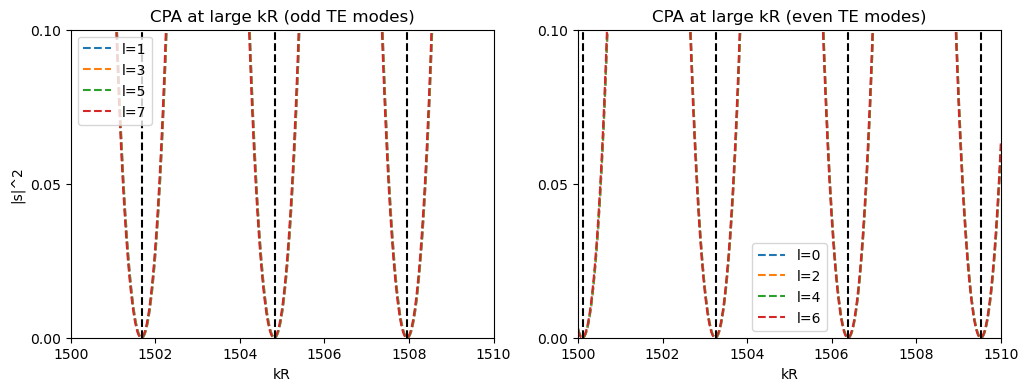

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for (l_indx, l) in enumerate(l_odd_array):
    ax1.plot(x, sabs_odd_array[l_indx, :], linestyle="dashed", label=f"l={int(l)}")
ax1.set_ylim(0, 0.1)
ax1.set_xlim(1500, 1510)
ax1.set_yticks([0, 0.05, 0.1])
ax1.set_xlabel("kR")
ax1.set_ylabel("|s|^2");
ax1.legend()
ax1.vlines(pi * linspace(1, 1000, 1000)/sqrt(epsilon), 0, 1, color="black", linestyle="dashed");
ax1.set_title("CPA at large kR (odd TE modes)")

for (l_indx, l) in enumerate(l_even_array):
    ax2.plot(x, sabs_even_array[l_indx, :], linestyle="dashed", label=f"l={int(l)}")
ax2.set_ylim(0, 0.1)
ax2.set_xlim(1500, 1510)
ax2.set_yticks([0, 0.05, 0.1])
ax2.set_xlabel("kR");
ax2.legend();
#ax2.set_ylabel("|s|^2");
ax2.vlines([pi/2/sqrt(epsilon)]+ pi * linspace(1, 1000, 1000)/sqrt(epsilon), 0, 1, color="black", linestyle="dashed");
ax2.set_title("CPA at large kR (even TE modes)");

### Now we look at subwavelength (kR<1). We look at $g(\omega)\approx -(l\times\epsilon+(l+1))/(l\times(l+1))$ corresponding to the quasistatic limit of the TM plasmon dispersion

In [7]:
M = 1000
N = 5000
g_omegas = linspace(-1.515, -1.509, M).reshape((M, 1)).repeat(N, 1)
epsilon_imaginary = linspace(0.002, 0.0021, N).reshape((1, N)).repeat(M, 0)

In [8]:
x = 0.1
l = 1
real_epsilon = 1
epsilon = real_epsilon + 1j*epsilon_imaginary
y = x * sqrt(epsilon) # epsilonkR in the sphere

xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)

numerator = epsilon * spherical_jn(l, y) * xhl2_prime - yjl_prime * hl2(l, x) + g_omegas * xhl2_prime * yjl_prime
denominator = -epsilon * spherical_jn(l, y) * xhl1_prime + yjl_prime * hl1(l, x) - g_omegas * xhl1_prime * yjl_prime

In [9]:
print("Minimum |s|^2: ", min(abs(numerator/denominator)**2))
idxs = unravel_index(argmin(abs(numerator/denominator)**2), numerator.shape)
print("CPA imepsilon: ", epsilon_imaginary[idxs], " and CPA g(omega): ", g_omegas[idxs])

Minimum |s|^2:  8.568465610363167e-07
CPA imepsilon:  0.002015963192638528  and CPA g(omega):  -1.5105015015015013


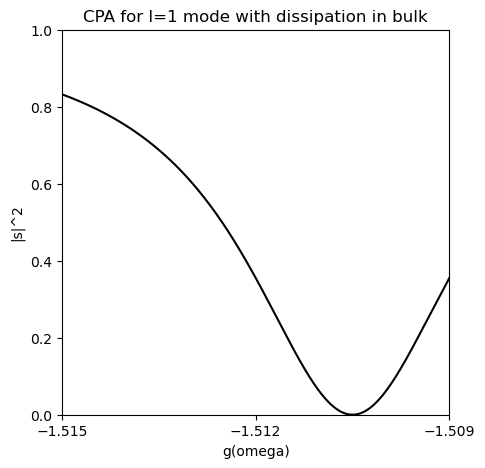

In [11]:
x1 = g_omegas[0, idxs[1]]
x2 = g_omegas[-1, idxs[1]]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(g_omegas[:, idxs[1]], (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 1)
ax.set_xlim(x1, x2);
ax.set_xticks([x1, (x1+x2)/2, x2]);
ax.set_xlabel("g(omega)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=1 mode with dissipation in bulk");

### We do the same as above but with dissipation in the surface

In [73]:
M = 5000
N = 5000
g_omegas = linspace(-1.5, -1.52, M).reshape((M, 1)).repeat(N, 1)
g_omegas_imaginary = linspace(0.0009, 0.0012, N).reshape((1, N)).repeat(M, 0)

In [74]:
x = 0.1
l = 1
real_epsilon = 1
epsilon = real_epsilon 
y = x * sqrt(epsilon) # epsilonkR in the sphere

xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)

numerator = epsilon * spherical_jn(l, y) * xhl2_prime - yjl_prime * hl2(l, x) + (g_omegas + 1j*g_omegas_imaginary) * xhl2_prime * yjl_prime
denominator = -epsilon * spherical_jn(l, y) * xhl1_prime + yjl_prime * hl1(l, x) - (g_omegas + 1j*g_omegas_imaginary) * xhl1_prime * yjl_prime

In [75]:
print("Minimum |s|^2: ", min(abs(numerator/denominator)**2))
idxs = unravel_index(argmin(abs(numerator/denominator)**2), numerator.shape)
print("CPA g_omega imaginary: ", g_omegas_imaginary[idxs], " and CPA g(omega): ", g_omegas[idxs])

Minimum |s|^2:  5.767652981241555e-07
CPA g_omega imaginary:  0.00101000200040008  and CPA g(omega):  -1.510498099619924


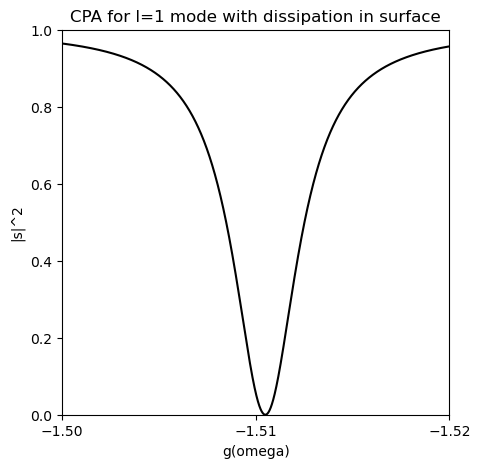

In [76]:
x1 = g_omegas[0, idxs[1]]
x2 = g_omegas[-1, idxs[1]]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(g_omegas[:, idxs[1]], (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 1)
ax.set_xlim(x1, x2);
ax.set_xticks([x1, (x1+x2)/2, x2]);
ax.set_xlabel("g(omega)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=1 mode with dissipation in surface");

In [136]:
l = 2
M = 1000
N = 5000
g_omegas = -0.8333333333333334 + linspace(-0.000997, -0.000995, M).reshape((M, 1)).repeat(N, 1)
epsilon_imaginary = linspace(0.00000082, 0.0000084, N).reshape((1, N)).repeat(M, 0)

In [137]:
x = 0.1
l = 2
real_epsilon = 1
epsilon = real_epsilon + 1j*epsilon_imaginary
y = x * sqrt(epsilon) # epsilonkR in the sphere

xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)

numerator = epsilon * spherical_jn(l, y) * xhl2_prime - yjl_prime * hl2(l, x) + g_omegas * xhl2_prime * yjl_prime
denominator = -epsilon * spherical_jn(l, y) * xhl1_prime + yjl_prime * hl1(l, x) - g_omegas * xhl1_prime * yjl_prime

In [138]:
print("Minimum |s|^2: ", min(abs(numerator/denominator)**2))
idxs = unravel_index(argmin(abs(numerator/denominator)**2), numerator.shape)
print("CPA imepsilon: ", epsilon_imaginary[idxs], " and CPA g(omega): ", g_omegas[idxs])

Minimum |s|^2:  1.8858464712216435e-06
CPA imepsilon:  8.32130426085217e-07  and CPA g(omega):  -0.8343296566566567


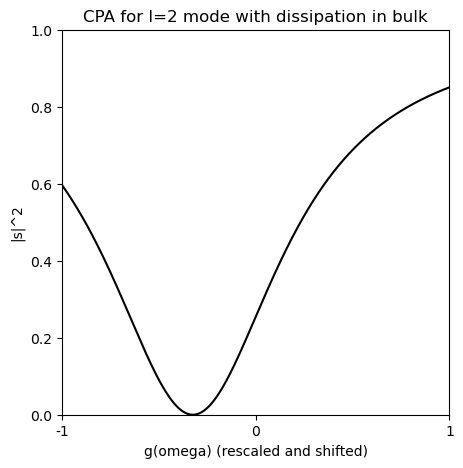

In [139]:
x1 = g_omegas[0, idxs[1]]
x2 = g_omegas[-1, idxs[1]]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(g_omegas[:, idxs[1]], (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 1)
ax.set_xlim(x1, x2);
ax.set_xticks([x1, (x1+x2)/2, x2], [-1, 0, 1]);
ax.set_xlabel("g(omega) (rescaled and shifted)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=2 mode with dissipation in bulk");

In [142]:
l = 2
M = 1000
N = 5000
g_omegas = -0.8343296296296296 + linspace(-1e-5, 1e-5, M).reshape((M, 1)).repeat(N, 1)
g_omegas_imaginary = linspace(2e-7, 3e-7, N).reshape((1, N)).repeat(M, 0)

In [143]:
x = 0.1
l = 2
real_epsilon = 1
epsilon = real_epsilon 
y = x * sqrt(epsilon) # epsilonkR in the sphere

xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)

numerator = epsilon * spherical_jn(l, y) * xhl2_prime - yjl_prime * hl2(l, x) + (g_omegas+1j*g_omegas_imaginary) * xhl2_prime * yjl_prime
denominator = -epsilon * spherical_jn(l, y) * xhl1_prime + yjl_prime * hl1(l, x) - (g_omegas+1j*g_omegas_imaginary) * xhl1_prime * yjl_prime

In [144]:
print("Minimum |s|^2: ", min(abs(numerator/denominator)**2))
idxs = unravel_index(argmin(abs(numerator/denominator)**2), numerator.shape)
print("CPA g_omega imaginary: ", g_omegas_imaginary[idxs], " and CPA g(omega): ", g_omegas[idxs])

Minimum |s|^2:  1.6445723759118897e-05
CPA g_omega imaginary:  2.777955591118223e-07  and CPA g(omega):  -0.8343296596596597


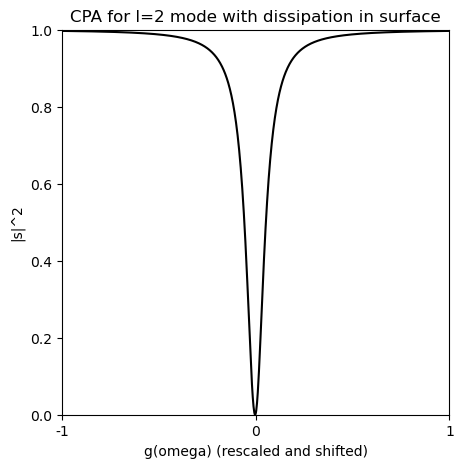

In [145]:
x1 = g_omegas[0, idxs[1]]
x2 = g_omegas[-1, idxs[1]]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(g_omegas[:, idxs[1]], (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 1)
ax.set_xlim(x1, x2);
ax.set_xticks([x1, (x1+x2)/2, x2], [-1, 0, 1]);
ax.set_xlabel("g(omega) (rescaled and shifted)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=2 mode with dissipation in surface");

### Now we look at subwavelength but for TE modes. We look at $g(\omega)\approx (2l+1)/x^2\rightarrow h(\omega)\equiv g(\omega)\times x^2 \approx 2l+1 $ corresponding to the small kR limit

In [185]:
M = 1000
N = 500
x = 0.1
# We define h_omegas to be g_omegas * x_0**2
h_omegas = linspace(2.98, 2.99, M).reshape((M, 1)).repeat(N, 1)
epsilon_imaginary = linspace(0.49, 0.50, N).reshape((1, N)).repeat(M, 0)

In [186]:
l = 1
real_epsilon = 1
epsilon = real_epsilon + 1j*epsilon_imaginary
y = x * sqrt(epsilon) # epsilonkR in the sphere

xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)

numerator = -spherical_jn(l, y) * xhl2_prime + yjl_prime * hl2(l, x) - h_omegas * spherical_jn(l, y) * hl2(l, x)
denominator = spherical_jn(l, y) * xhl1_prime - yjl_prime * hl1(l, x) + h_omegas * spherical_jn(l, y) * hl1(l, x)

In [187]:
idxs = unravel_index(argmin(abs(numerator/denominator)**2), numerator.shape)
print("Minimum |s|^2: ", min(abs(numerator/denominator)**2))
print("CPA imepsilon: ", epsilon_imaginary[idxs], " and CPA h(omega): ", h_omegas[idxs])

Minimum |s|^2:  5.881291727152345e-08
CPA imepsilon:  0.4947695390781563  and CPA h(omega):  2.9880980980980985


### Note that, as expected, $h(\omega)\approx 2\times 1 + 1 = 3$

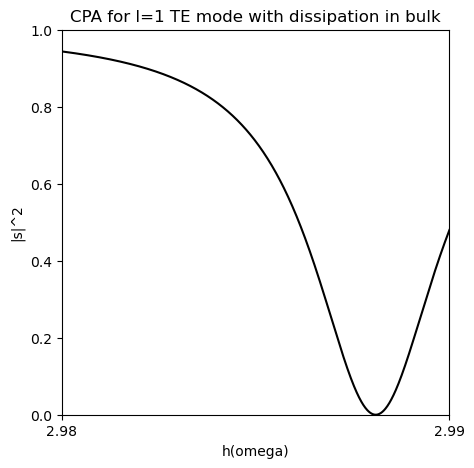

In [188]:
x1 = h_omegas[0, idxs[1]]
x2 = h_omegas[-1, idxs[1]]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(h_omegas[:, idxs[1]], (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 1)
ax.set_xticks([x1, x2])
ax.set_xlim(x1, x2);
ax.set_xlabel("h(omega)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=1 TE mode with dissipation in bulk");

In [189]:
M = 1000
N = 500
x = 0.1
# We define h_omegas to be g_omegas * x_0**2
h_omegas = linspace(2.98, 2.99, M).reshape((M, 1)).repeat(N, 1)
h_omegas_imaginary = linspace(0, 0.001, N).reshape((1, N)).repeat(M, 0)

In [190]:
l = 1
real_epsilon = 1
epsilon = real_epsilon
y = x * sqrt(epsilon) # epsilonkR in the sphere

xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)

numerator = -spherical_jn(l, y) * xhl2_prime + yjl_prime * hl2(l, x) - (h_omegas + 1j*h_omegas_imaginary) * spherical_jn(l, y) * hl2(l, x)
denominator = spherical_jn(l, y) * xhl1_prime - yjl_prime * hl1(l, x) +(h_omegas + 1j*h_omegas_imaginary) * spherical_jn(l, y) * hl1(l, x)

In [191]:
idxs = unravel_index(argmin(abs(numerator/denominator)**2), numerator.shape)
print("Minimum |s|^2: ", min(abs(numerator/denominator)**2))
print("CPA h_omega imaginary: ", h_omegas_imaginary[idxs], " and CPA h(omega): ", h_omegas[idxs])

Minimum |s|^2:  3.312016745232599e-08
CPA h_omega imaginary:  0.0009899799599198396  and CPA h(omega):  2.9880980980980985


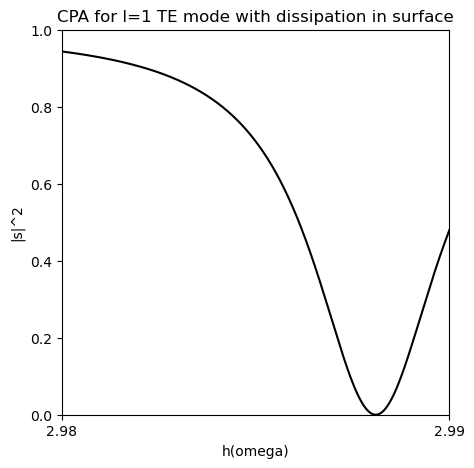

In [192]:
x1 = h_omegas[0, idxs[1]]
x2 = h_omegas[-1, idxs[1]]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(h_omegas[:, idxs[1]], (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 1)
ax.set_xticks([x1, x2])
ax.set_xlim(x1, x2);
ax.set_xlabel("h(omega)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=1 TE mode with dissipation in surface");

In [193]:
M = 1000
N = 2000
x = 0.1
# We define h_omegas to be g_omegas * x_0**2
h_omegas = linspace(4.995224, 4.995228, M).reshape((M, 1)).repeat(N, 1)
epsilon_imaginary = linspace(0.0007, 0.0008, N).reshape((1, N)).repeat(M, 0)

In [194]:
l = 2
real_epsilon = 1
epsilon = real_epsilon + 1j*epsilon_imaginary
y = x * sqrt(epsilon) # epsilonkR in the sphere

xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)

numerator = -spherical_jn(l, y) * xhl2_prime + yjl_prime * hl2(l, x) - h_omegas * spherical_jn(l, y) * hl2(l, x)
denominator = spherical_jn(l, y) * xhl1_prime - yjl_prime * hl1(l, x) + h_omegas * spherical_jn(l, y) * hl1(l, x)

In [195]:
idxs = unravel_index(argmin(abs(numerator/denominator)**2), numerator.shape)
print("CPA imepsilon: ", epsilon_imaginary[idxs], " and CPA h(omega): ", h_omegas[idxs])
print("Minimum |s|^2: ", min(abs(numerator/denominator)**2))

CPA imepsilon:  0.0007749374687343672  and CPA h(omega):  4.9952268308308305
Minimum |s|^2:  3.773187913815737e-08


### As expected, $h(\omega)\approx 2\times 2 + 1 = 5$

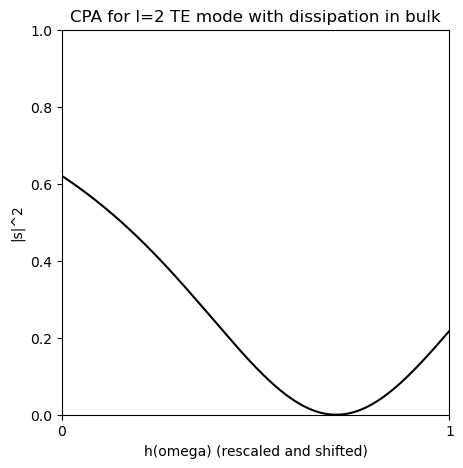

In [196]:
x1 = h_omegas[0, idxs[1]]
x2 = h_omegas[-1, idxs[1]]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(h_omegas[:, idxs[1]], (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 1)
ax.set_xticks([x1, x2], [0, 1])
ax.set_xlim(x1, x2);
ax.set_xlabel("h(omega) (rescaled and shifted)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=2 TE mode with dissipation in bulk");

In [222]:
M = 1000
N = 2000
x = 0.1
# We define h_omegas to be g_omegas * x_0**2
h_omegas = linspace(4.9952, 4.99523, M).reshape((M, 1)).repeat(N, 1)
h_omegas_imaginary = linspace(1e-6, 2e-6, N).reshape((1, N)).repeat(M, 0)

In [223]:
l = 2
real_epsilon = 1
epsilon = real_epsilon
y = x * sqrt(epsilon) # epsilonkR in the sphere

xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)

numerator = -spherical_jn(l, y) * xhl2_prime + yjl_prime * hl2(l, x) - (h_omegas + 1j*h_omegas_imaginary) * spherical_jn(l, y) * hl2(l, x)
denominator = spherical_jn(l, y) * xhl1_prime - yjl_prime * hl1(l, x) + (h_omegas + 1j*h_omegas_imaginary) * spherical_jn(l, y) * hl1(l, x)

In [224]:
idxs = unravel_index(argmin(abs(numerator/denominator)**2), numerator.shape)
print("Minimum |s|^2: ", min(abs(numerator/denominator)**2))
print("CPA h_omega imaginary: ", h_omegas_imaginary[idxs], " and CPA h(omega): ", h_omegas[idxs])

Minimum |s|^2:  4.2527936691199514e-05
CPA h_omega imaginary:  1.1075537768884442e-06  and CPA h(omega):  4.9952268168168175


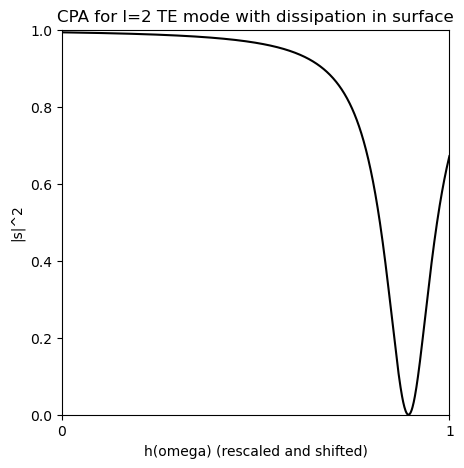

In [226]:
x1 = h_omegas[0, idxs[1]]
x2 = h_omegas[-1, idxs[1]]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(h_omegas[:, idxs[1]], (abs(numerator/denominator)**2)[:, idxs[1]], color="black")
ax.set_ylim(0, 1)
ax.set_xticks([x1, x2], [0, 1])
ax.set_xlim(x1, x2);
ax.set_xlabel("h(omega) (rescaled and shifted)")
ax.set_ylabel("|s|^2");
ax.set_title("CPA for l=2 TE mode with dissipation in surface");